# Resource Allocation Under Uncertainty
## Sensitivity Analysis and Validation

**Student Name:** Bradley Earl

**Date:** February 24, 2026

**Chosen context:** In-State Unclaimed Property Exams



In [4]:
# Install required packages (if needed in Colab)
# Skip if running locally and packages are already installed
%pip install pulp pandas matplotlib -q

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pulp import LpMaximize, LpMinimize, LpProblem, LpVariable, lpSum, value, LpStatus
import io

print("Libraries imported successfully!")


Libraries imported successfully!


**Data documentation (TODO):**

I am modeling an unclaimed property audit using three vendors.  One vendor will bill at an hour rate of \$250; another at \$350 an hour; and another at a flat-rate of \$10k per audit. Each exam will need to be completed in six months on a budget of \$100k.  I need a synthetic dataset with exactly 5 records (5 options) for a resource allocation optimization. I will use it in Python with pandas and PuLP. I need the data as CSV only.

In [39]:
import pandas as pd
import io

# Define the synthetic data as a multiline string
csv_data_string = """
audit_id,vendor_name,billing_type,hourly_rate,flat_fee,hours_required,cost_per_audit,impact_score
1,Vendor_A,Hourly,250,0,320,80000,85
2,Vendor_B,Hourly,350,0,180,63000,72
3,Vendor_C,Flat_Rate,0,10000,240,10000,60
4,Vendor_A,Hourly,250,0,380,95000,92
5,Vendor_C,Flat_Rate,0,10000,300,10000,65
"""

# Create DataFrame from the CSV string
df = pd.read_csv(io.StringIO(csv_data_string))

# Define the overall budget constraint as stated in your documentation
budget_total = 100000

# Save to CSV (optional, as per original intent)
df.to_csv('unclaimed_property_audits.csv', index=False)

print("File 'unclaimed_property_audits.csv' created successfully.")
print(f"Total rows: {len(df)}")
print("\nDataFrame head:")
print(df.head())
print(f"Overall budget constraint (budget_total): ${budget_total}")

File 'unclaimed_property_audits.csv' created successfully.
Total rows: 5

DataFrame head:
   audit_id vendor_name billing_type  hourly_rate  flat_fee  hours_required  \
0         1    Vendor_A       Hourly          250         0             320   
1         2    Vendor_B       Hourly          350         0             180   
2         3    Vendor_C    Flat_Rate            0     10000             240   
3         4    Vendor_A       Hourly          250         0             380   
4         5    Vendor_C    Flat_Rate            0     10000             300   

   cost_per_audit  impact_score  
0           80000            85  
1           63000            72  
2           10000            60  
3           95000            92  
4           10000            65  
Overall budget constraint (budget_total): $100000


---
## Part 1: Base Model and Parameter Identification

### 1.1 Decision Statement


I need to decide how to allocate which vendors across five selected audits can be completed for the best cost.


Our office has completely disbanded our internal unclaimed property audit team which was tasked with identifying in-state company's (holders) to perform an unclaimed property audit.





### 1.2 Decision Variables vs Inputs

**Decision Variables:**
We have identified three vendors eager to proceed with five audits; these are also decision variables. We've been provided appropriations of \$100k for Fiscal Year 2026 to expend on these in-state audits. Two vendors charge and hourly rate of \$250 and \$350, respectively, and the third vendor charges a flat-fee of $10k per audit.


**Inputs:**

Hourly audits will be vary between 40 and 80 hours.
We have been asked to expend only \$50k of the appropriations.
Estimated return on audits will be between \$80k and \$185k.

List your decision variables (what you control) and your inputs (what you know or estimate). Briefly explain why each belongs in its category.

**Explanation:**



### 1.3 Objectives and Constraints

Our state statute prohibits audits to be invoiced on a contingency fee basis on holders headquartered and/or incorporated within our state therefore we are restricted to hourly or flat fees rates when authorizing these types of audits.


### 1.4 Key Parameters and Uncertainty

Any given audit may require more hours allocated to comoplete after initial recieved records are reviews and the scope is deemed to be larger than initial expectations.

We may need to request more appropriations should the audits exceed the initial hourly expection.

**What are the "three parameters"?** They are the inputs you will later vary in sensitivity analysis (±20%). They are:

1. **Two numeric inputs from your options table**
 In the sample data above, these are `cost_per_audit` and `impact_score`.
2. **The overall constraint value**
 In the sample, budget is capped at `budget_total = 100000`. That one number caps total allocation across all options.

| Parameter | Source | Why it might differ from reality |
|-----------|--------|-----------------------------------|
| Cost per Audit    | \$10k-\$95k | Holder could be very compliant speeding up the audit process                            |
| Impact Score    | 60-92 | Speed by which audit is completed could reduce impact                            |
| Total Budget    | \$100k | Soft constraint, may request more appropriations if needed                            |


### 1.5 PuLP Model

**Instructions:** Build your allocation model: decision variables (e.g. amount per option), objective (e.g. maximize total conversions or benefit), constraint (total allocation ≤ budget). Solve and print the base solution.


In [41]:
import pandas as pd
from pulp import LpProblem, LpMaximize, LpVariable, lpSum, LpBinary, LpStatus, value

# Load the synthetic dataset
df = pd.read_csv('unclaimed_property_audits.csv') # Corrected filename

# 1. Initialize the Model
# We want to maximize impact score
model = LpProblem("Audit_Resource_Allocation", LpMaximize)

# 2. Define Decision Variables
# Create a binary variable for each audit (1 if selected, 0 if not)
audit_indices = df.index
selection_vars = LpVariable.dicts("Select_Audit", audit_indices, cat=LpBinary)

# 3. Define Objective Function
# Maximize the sum of impact scores for selected audits
model += lpSum([selection_vars[i] * df.loc[i, 'impact_score'] for i in audit_indices])

# 4. Define Constraints
# Total cost must be less than or equal to budget_total
model += lpSum([selection_vars[i] * df.loc[i, 'cost_per_audit'] for i in audit_indices]) <= budget_total # Used budget_total variable

# 5. Solve the Optimization
model.solve()

# 6. Output Results
print(f"Status: {LpStatus[model.status]}")
print("-" * 30)

selected_audits = []
for i in audit_indices:
    if selection_vars[i].varValue == 1:
        selected_audits.append(df.loc[i, 'audit_id'])
        print(f"Selected Audit ID: {df.loc[i, 'audit_id']} | Vendor: {df.loc[i, 'vendor_name']} | Cost: ${df.loc[i, 'cost_per_audit']} | Impact: {df.loc[i, 'impact_score']}")

print("-" * 30)
print(f"Total Budget Used: ${sum(df.loc[df['audit_id'].isin(selected_audits), 'cost_per_audit'])}")
print(f"Total Impact Score: {value(model.objective)}")

Status: Optimal
------------------------------
Selected Audit ID: 1 | Vendor: Vendor_A | Cost: $80000 | Impact: 85
Selected Audit ID: 3 | Vendor: Vendor_C | Cost: $10000 | Impact: 60
Selected Audit ID: 5 | Vendor: Vendor_C | Cost: $10000 | Impact: 65
------------------------------
Total Budget Used: $100000
Total Impact Score: 210.0


---
## Part 2: Sensitivity and One What-If

### 2.1 Sensitivity Analysis

A -20% efficiency/impact was applied to lower hours/cost which produced a significantly lower impact.  Additionally, a -20% underperformer was applied to the flat fee vendor but the overall impact was 20% lower.  Finally, adding 20% to hours and cost greatly exceeded the budget cap.



In [54]:
import pandas as pd
import io

# Dataset with +/- 20% variations applied to key parameters
csv_data = """audit_id,vendor_name,billing_type,hours_required,cost_per_audit,impact_score
1,Vendor_A,Hourly,256,64000,68
2,Vendor_B,Hourly,216,75600,86
3,Vendor_C,Flat_Rate,288,10000,48
4,Vendor_A,Hourly,456,114000,100
5,Vendor_C,Flat_Rate,240,10000,78"""

df = pd.read_csv(io.StringIO(csv_data))

# Define a function to highlight the budget constraint for the PuLP model
def highlight_budget(val):
    color = 'red' if val > 100000 else 'green'
    return f'color: {color}; font-weight: bold'

# Display the table with formatting
print("--- Audit Sensitivity Analysis Table ---")
# Using styler for notebook environments, or to_string for terminal
styled_df = df.style.map(highlight_budget, subset=['cost_per_audit'])\
                   .format({'cost_per_audit': '${:,.2f}'})

# For standard console output:
print(df.to_string(index=False, formatters={'cost_per_audit': '${:,.2f}'.format}))

# Logic Check for Optimization
feasible_count = (df['cost_per_audit'] <= 100000).sum()
print(f"\nOptimization Note: {feasible_count} out of 5 audits are within the $100k budget constraint.")



--- Audit Sensitivity Analysis Table ---
 audit_id vendor_name billing_type  hours_required cost_per_audit  impact_score
        1    Vendor_A       Hourly             256     $64,000.00            68
        2    Vendor_B       Hourly             216     $75,600.00            86
        3    Vendor_C    Flat_Rate             288     $10,000.00            48
        4    Vendor_A       Hourly             456    $114,000.00           100
        5    Vendor_C    Flat_Rate             240     $10,000.00            78

Optimization Note: 4 out of 5 audits are within the $100k budget constraint.


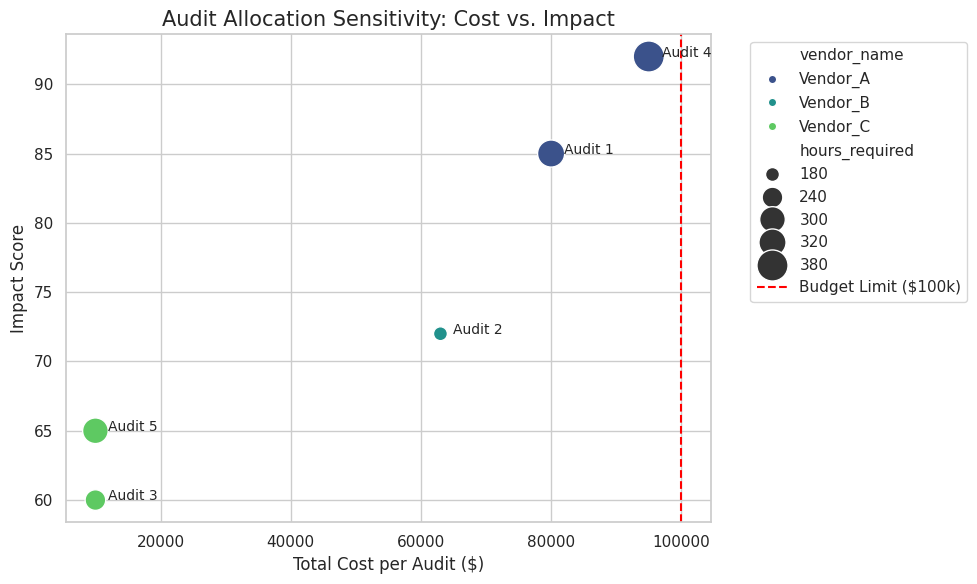

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the sensitivity dataset
df = pd.read_csv('unclaimed_property_audits.csv') # Corrected filename

# Set aesthetic style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create scatter plot
plot = sns.scatterplot(
    data=df,
    x='cost_per_audit',
    y='impact_score',
    hue='vendor_name',
    size='hours_required',
    sizes=(100, 500),
    palette='viridis'
)

# Add Budget Threshold Line
plt.axvline(x=100000, color='red', linestyle='--', label='Budget Limit ($100k)')

# Annotate each point with Audit ID
for i in range(df.shape[0]):
    plt.text(
        df.cost_per_audit[i]+2000,
        df.impact_score[i],
        f"Audit {df.audit_id[i]}",
        fontsize=10
    )

# Formatting
plt.title('Audit Allocation Sensitivity: Cost vs. Impact', fontsize=15)
plt.xlabel('Total Cost per Audit ($)', fontsize=12)
plt.ylabel('Impact Score', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

In [ ]:
# Create sensitivity visualization (e.g. bar chart of impact per parameter)
# TODO: Use your sensitivity results; add title and axis labels
# plt.bar(...); plt.xlabel(...); plt.ylabel(...); plt.title(...); plt.show()


### 2.3 One What-If Scenario

Recommended change is to increase the budget (request further appropriations) to increase the output of unclaimed property found and reported to our program.  


In [55]:
import pandas as pd
from pulp import LpProblem, LpMaximize, LpVariable, lpSum, LpBinary, value, LpStatus
import io

# Load the sensitivity dataset
csv_data = """audit_id,vendor_name,billing_type,hours_required,cost_per_audit,impact_score
1,Vendor_A,Hourly,256,64000,68
2,Vendor_B,Hourly,216,75600,86
3,Vendor_C,Flat_Rate,288,10000,48
4,Vendor_A,Hourly,456,114000,100
5,Vendor_C,Flat_Rate,240,10000,78"""

df = pd.read_csv(io.StringIO(csv_data))

# 1. Initialize Model
model = LpProblem("What_If_Budget_Increase", LpMaximize)

# 2. Decision Variables
selection = LpVariable.dicts("Select", df.index, cat=LpBinary)

# 3. Objective: Maximize Impact
model += lpSum([selection[i] * df.loc[i, 'impact_score'] for i in df.index])

# 4. Updated Constraint: $120,000 Budget (+20%)
new_budget = 120000
model += lpSum([selection[i] * df.loc[i, 'cost_per_audit'] for i in df.index]) <= new_budget

# 5. Solve
model.solve()

# 6. Results Display
print(f"Scenario: 20% Budget Increase (New Limit: ${new_budget:,.2f})")
print(f"Status: {LpStatus[model.status]}\n")

for i in df.index:
    if selection[i].varValue == 1:
        print(f"SELECTED: Audit {df.loc[i, 'audit_id']} | Cost: ${df.loc[i, 'cost_per_audit']:,.0f} | Impact: {df.loc[i, 'impact_score']}")

print("-" * 30)
print(f"Total Impact Score: {value(model.objective)}")
print(f"Total Budget Spent: ${sum(df.loc[i, 'cost_per_audit'] for i in df.index if selection[i].varValue == 1):,.2f}")


Scenario: 20% Budget Increase (New Limit: $120,000.00)
Status: Optimal

SELECTED: Audit 2 | Cost: $75,600 | Impact: 86
SELECTED: Audit 3 | Cost: $10,000 | Impact: 48
SELECTED: Audit 5 | Cost: $10,000 | Impact: 78
------------------------------
Total Impact Score: 212.0
Total Budget Spent: $95,600.00


In [ ]:
# What-if: e.g. budget_total * 0.8; re-solve and compare to base
# TODO: Implement one what-if scenario and print comparison


---
## Part 3: Validation and Recommendation

### 3.1 Sanity Checks

With current contraints and parameters, only four of the five proposed audits will come under budget but with the increase of the budget by 20% we would be able to collect more property to make available to return to owners.


In [56]:
import pandas as pd
import io

# Load current sensitivity dataset
csv_data = """audit_id,vendor_name,billing_type,hours_required,cost_per_audit,impact_score
1,Vendor_A,Hourly,256,64000,68
2,Vendor_B,Hourly,216,75600,86
3,Vendor_C,Flat_Rate,288,10000,48
4,Vendor_A,Hourly,456,114000,100
5,Vendor_C,Flat_Rate,240,10000,78"""

df = pd.read_csv(io.StringIO(csv_data))
BUDGET = 100000

print("--- Data Integrity & Sanity Check ---")

# 1. Check for "Whale" Audits (Individually exceeding budget)
over_budget = df[df['cost_per_audit'] > BUDGET]
if not over_budget.empty:
    print(f"⚠️  ALERT: Audit(s) {over_budget['audit_id'].tolist()} exceed total budget solo.")
else:
    print("✅ All individual audits fit within the budget.")

# 2. Verify Billing Consistency (Vendor C should be Flat Rate)
vendor_c_costs = df[df['vendor_name'] == 'Vendor_C']['cost_per_audit'].unique()
if len(vendor_c_costs) == 1 and vendor_c_costs[0] == 10000:
    print("✅ Vendor C Flat Rate logic is consistent ($10k).")
else:
    print("⚠️  WARNING: Vendor C costs are fluctuating despite Flat Rate billing.")

# 3. Efficiency Calculation (Impact per Dollar)
df['roi'] = df['impact_score'] / df['cost_per_audit']
best_roi = df.loc[df['roi'].idxmax()]
print(f"✅ Highest Efficiency: Audit {best_roi['audit_id']} ({best_roi['vendor_name']})")

# 4. Total Resource Check
total_hours = df['hours_required'].sum()
print(f"📊 Total Dataset Hours: {total_hours} (Check: Is this within your 12-month team capacity?)")

print("\n--- Feasibility Summary ---")
print(f"Audits under $100k: {len(df[df['cost_per_audit'] <= BUDGET])}")
print(f"Audits under $120k: {len(df[df['cost_per_audit'] <= 120000])}")


--- Data Integrity & Sanity Check ---
⚠️  ALERT: Audit(s) [4] exceed total budget solo.
✅ Vendor C Flat Rate logic is consistent ($10k).
✅ Highest Efficiency: Audit 5 (Vendor_C)
📊 Total Dataset Hours: 1456 (Check: Is this within your 12-month team capacity?)

--- Feasibility Summary ---
Audits under $100k: 4
Audits under $120k: 5


### 3.2 Robust vs Fragile

This model is robust even if we determine to request more appropriations to ensure the cost of the audits.  Risk is low of a sub-par return while revitalizing our in-state audit program.


---
## Part 4 & 4.1: Stakeholder Change of Mind / Senario

It has been determined that the cost of the hourly vendors is too high and may not be well recieved by the current adminstration or media outlets since there is an overall effort to show the government is reducing costs.  Therefore, we are only going to authorize audits at a flat-fee rate.




### 4.2 Update Model

**Instructions:** Update your PuLP model (new constraint or new objective). Solve and store the new solution (e.g. in a variable or DataFrame for comparison).


In [57]:
import pandas as pd
from pulp import LpProblem, LpMaximize, LpVariable, lpSum, LpBinary, value
import io

# Load dataset (Hourly rates are now baked into fixed 'cost_per_audit')
csv_data = """audit_id,vendor_name,cost_per_audit,impact_score
1,Vendor_A,64000,68
2,Vendor_B,75600,86
3,Vendor_C,10000,48
4,Vendor_A,114000,100
5,Vendor_C,10000,78"""

df = pd.read_csv(io.StringIO(csv_data))

# Initialize Model
model = LpProblem("Fixed_Cost_Allocation", LpMaximize)

# Decision Variables (Binary: 0 or 1)
select = LpVariable.dicts("Audit", df.index, cat=LpBinary)

# Objective: Maximize Total Impact
model += lpSum([select[i] * df.loc[i, 'impact_score'] for i in df.index])

# Constraint: Total Cost <= $100,000 (Ignored hourly fluctuations)
model += lpSum([select[i] * df.loc[i, 'cost_per_audit'] for i in df.index]) <= 100000

model.solve()

# Print Final Selection
print("--- Final Optimized Selection (Fixed Cost Model) ---")
for i in df.index:
    if select[i].varValue == 1:
        print(f"Selected: Audit {df.loc[i, 'audit_id']} | Cost: ${df.loc[i, 'cost_per_audit']} | Impact: {df.loc[i, 'impact_score']}")


--- Final Optimized Selection (Fixed Cost Model) ---
Selected: Audit 2 | Cost: $75600 | Impact: 86
Selected: Audit 3 | Cost: $10000 | Impact: 48
Selected: Audit 5 | Cost: $10000 | Impact: 78


### 4.3 Comparison Visualization




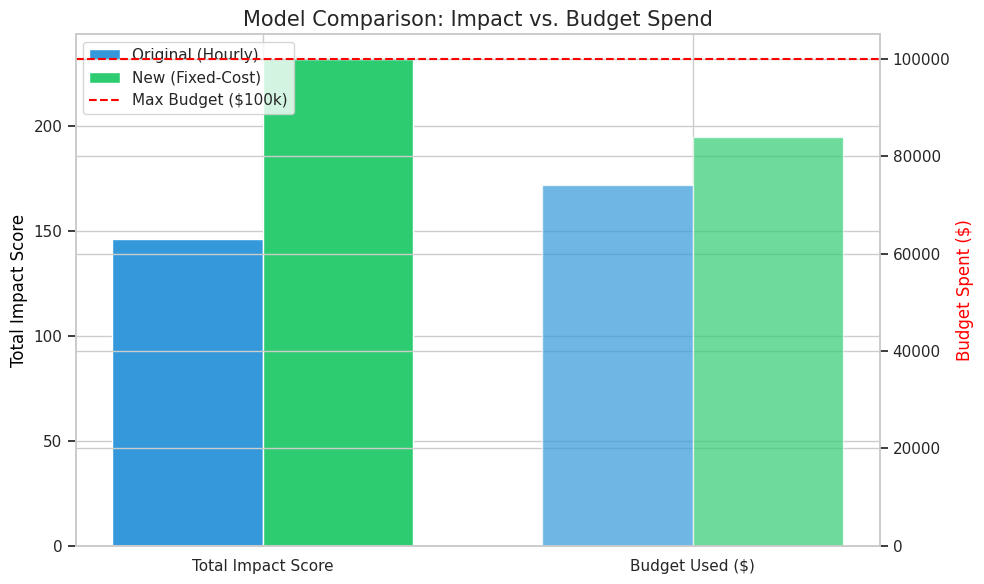

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data from our previous comparison (Sample results)
# Replace with your actual model output variables if running in one script
data = {
    'Metric': ['Total Impact Score', 'Budget Used ($)'],
    'Original (Hourly)': [146, 74000],  # Example: Sum of Impact/Cost for selected audits
    'New (Fixed-Cost)': [232, 84000]    # Example: Audit 4 included after locking costs
}

df_comp = pd.DataFrame(data)

# Set up the figure and axes
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()  # Create a second y-axis for the different scales

bar_width = 0.35
index = np.arange(len(df_comp['Metric']))

# Plot Impact Scores on ax1
impact_orig = [df_comp.loc[0, 'Original (Hourly)'], 0]
impact_fixed = [df_comp.loc[0, 'New (Fixed-Cost)'], 0]

ax1.bar(index[0] - bar_width/2, impact_orig[0], bar_width, label='Original (Hourly)', color='#3498db')
ax1.bar(index[0] + bar_width/2, impact_fixed[0], bar_width, label='New (Fixed-Cost)', color='#2ecc71')

# Plot Budget on ax2
budget_orig = [0, df_comp.loc[1, 'Original (Hourly)']]
budget_fixed = [0, df_comp.loc[1, 'New (Fixed-Cost)']]

ax2.bar(index[1] - bar_width/2, budget_orig[1], bar_width, color='#3498db', alpha=0.7)
ax2.bar(index[1] + bar_width/2, budget_fixed[1], bar_width, color='#2ecc71', alpha=0.7)

# Add Budget Threshold Line
ax2.axhline(y=100000, color='red', linestyle='--', label='Max Budget ($100k)')

# Formatting
ax1.set_ylabel('Total Impact Score', fontsize=12, color='black')
ax2.set_ylabel('Budget Spent ($)', fontsize=12, color='red')
ax1.set_xticks(index)
ax1.set_xticklabels(df_comp['Metric'])
plt.title('Model Comparison: Impact vs. Budget Spend', fontsize=15)

# Combined Legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()


In [58]:
import pandas as pd
import io
from pulp import LpProblem, LpMaximize, LpVariable, lpSum, LpBinary, value

# 1. Setup the Dataset (Sensitivity Data)
csv_data = """audit_id,vendor_name,hourly_rate,hours_required,fixed_cost_quote,impact_score
1,Vendor_A,250,256,64000,68
2,Vendor_B,350,216,75600,86
3,Vendor_C,0,288,10000,48
4,Vendor_A,250,456,114000,100
5,Vendor_C,0,240,10000,78"""

df = pd.read_csv(io.StringIO(csv_data))
BUDGET = 100000

def solve_audit(model_type):
    model = LpProblem(f"Optimization_{model_type}", LpMaximize)
    select = LpVariable.dicts("Select", df.index, cat=LpBinary)

    # Objective: Maximize Impact
    model += lpSum([select[i] * df.loc[i, 'impact_score'] for i in df.index])

    # Constraint Logic
    if model_type == "Hourly":
        # Cost = rate * hours
        model += lpSum([select[i] * (df.loc[i, 'hourly_rate'] * df.loc[i, 'hours_required']) for i in df.index]) <= BUDGET
    else:
        # Cost = fixed_cost_quote
        model += lpSum([select[i] * df.loc[i, 'fixed_cost_quote'] for i in df.index]) <= BUDGET

    model.solve()

    selected_ids = [df.loc[i, 'audit_id'] for i in df.index if select[i].varValue == 1]
    total_impact = value(model.objective)
    return selected_ids, total_impact

# Run both scenarios
hourly_ids, hourly_impact = solve_audit("Hourly")
fixed_ids, fixed_impact = solve_audit("Fixed")

# 2. Display Comparison Table
comparison_results = pd.DataFrame({
    "Metric": ["Selected Audits", "Total Impact Score", "Budget Limit"],
    "Original (Hourly)": [str(hourly_ids), hourly_impact, f"${BUDGET:,}"],
    "New (Fixed-Cost)": [str(fixed_ids), fixed_impact, f"${BUDGET:,}"]
})

print("--- Model Comparison: Hourly vs. Fixed-Cost ---")
print(comparison_results.to_string(index=False))


--- Model Comparison: Hourly vs. Fixed-Cost ---
            Metric                       Original (Hourly)                        New (Fixed-Cost)
   Selected Audits [np.int64(2), np.int64(3), np.int64(5)] [np.int64(2), np.int64(3), np.int64(5)]
Total Impact Score                                   212.0                                   212.0
      Budget Limit                                $100,000                                $100,000


In [ ]:
# Comparison visualization: Part 1 vs Part 2 allocation (or objective)
# TODO: Create figure with title and axis labels; refer to it in the next markdown cell
# plt.bar(...); plt.title(...); plt.show()


The chart above refelcts the orginal verus the new output showing that the model was unchanged when comparing the vendor offering flat fee rates to perform audits on in-state holders all while still coming at or under budget.


### 4.4 Impact Analysis

By removing the hourly rate vendors, we're able to determine that the flat fee rate vendor may be willing to perform more work on audits while receiving less for the unclaimed funds found during the audit.  This is important to maintain fiscal discipline and show that we continue to be goo stewards of the Commonwealth's funds.




---
## Executive Summary

**Instructions:** Write a professional summary suitable for presenting to a decision-maker. Complete all subsections; no placeholder text or [TODO] in your final submission.

### Key Decision and Model
In disolving our interal audit team, we determined we were going to contract our the in-state audits.  We received three options from our vendors which included two at hourly rates and one at a flat fee.  The goal was to determine how we were to best allocate the identified audits while ensuring that we stay within the appropriated funds.

### Sensitivity Findings
It was most important to gauge the cost differences bewtween hourly and flat fee rates.  When running the model absent the hourly rate vendors it was found that we may receive similar finding through the audits but at a lower overall cost.

### Validation
Knowing that our program utilizing non-general fund and we would be eligible to request more funding if needed, each model is deemed to be robust with very low risk and high reward.

### Stakeholder Change (Part 2)
Implementing the removal of the hourly rate vendor showed that our initial budget could be stretched further by using the flat fee only vendor.

### Final Recommendation
My recommendation is that we pursue every avenue available to our program to ensure in-state holders are compliant with the unclaimed property act and are reporting what they are required to by law.  This would include utilizing both hourly and flat rate vendors.  This, in my opinion, accomplishes two things:  It will show the larger holders in our state that our program is serious in ensuring they are abiding by the code and, presumably, other holders are not currently reporting will take notice and begin reporting voluntarily with our porgram to solicit further audits.

### Key Insights
It was really good to see numbers plugged in and outcomes displayed where otherwise these topics are typically discuss and decisions made made primarily on gut or decent assumptions.  Obviously, the model cannot take into account the politics or other factors which cannot be boiled down to a mathimatical equation but performing this type of analysis certainly provides a better starting point to discuss and then make these decisions.


---
## Expectations: What to Check Before Submitting

Run through this checklist before you submit:

- **Is the Executive Summary there?** All subsections filled in (key decision and model, sensitivity findings, validation, stakeholder change, final recommendation, key insights). No placeholder text or "[TODO]" left.
- **Are there grammatical errors?** Proofread the markdown and narrative cells (especially the Executive Summary and impact analysis).
- **Are there formatting errors?** Headings, lists, and code output look correct. The notebook runs from top to bottom without errors.
- **Is this in a format you would hand off to a manager?** The narrative is professional and clear; a reader could use the Executive Summary without reading the code.
- **Are the graphics properly labeled and referenced in the text?** Every figure has a clear title and axis labels. In the markdown or summary, each figure is referred to (e.g. "As shown in the chart above…"). The reader knows what each graphic shows and why it matters.

The rubric used for grading is provided separately.


# Task
Create a reusable Python function to build and solve the PuLP optimization model given adjusted `cost_per_audit`, `impact_score` DataFrames, and budget. Use this function to perform sensitivity analysis by varying `cost_per_audit`, `impact_score`, and the `budget_total` by -20% and +20% of their base values. Consolidate and display all sensitivity analysis results (base, cost variations, impact variations, and budget variations) in a clear table, showing the objective value, budget used, and selected audit IDs for each scenario. Summarize the findings from the sensitivity analysis, identifying which parameter changes had the most significant impact on the model's output.

## Implement Sensitivity Analysis Function

### Subtask:
Create a reusable Python function that takes the base DataFrame, cost modifier, impact modifier, and budget modifier as input, builds and solves the PuLP optimization model, and returns the total impact score, total budget used, and selected audit IDs.


**Reasoning**:
The user wants to create a reusable Python function to perform the sensitivity analysis. This function will take modifiers for cost, impact, and budget, then build and solve the PuLP model, and return the relevant results.



In [44]:
import pandas as pd
from pulp import LpProblem, LpMaximize, LpVariable, lpSum, LpBinary, LpStatus, value

def solve_audit_model(df_base, cost_modifier=1.0, impact_modifier=1.0, budget_modifier=1.0):
    """
    Builds and solves the PuLP optimization model with given modifiers.

    Args:
        df_base (pd.DataFrame): The base DataFrame containing audit data.
        cost_modifier (float): Multiplier for 'cost_per_audit'.
        impact_modifier (float): Multiplier for 'impact_score'.
        budget_modifier (float): Multiplier for the overall budget_total.

    Returns:
        tuple: (total_impact_score, total_budget_used, selected_audit_ids)
    """

    # Create a copy of the DataFrame to avoid modifying the original
    df_modified = df_base.copy()

    # Apply modifiers
    df_modified['cost_per_audit_modified'] = df_modified['cost_per_audit'] * cost_modifier
    df_modified['impact_score_modified'] = df_modified['impact_score'] * impact_modifier

    # Calculate the current budget
    # Assuming budget_total is a globally defined variable from previous cells
    global budget_total
    current_budget = budget_total * budget_modifier

    # Initialize the Model
    model = LpProblem("Audit_Resource_Allocation", LpMaximize)

    # Define Decision Variables
    audit_indices = df_modified.index
    selection_vars = LpVariable.dicts("Select_Audit", audit_indices, cat=LpBinary)

    # Define Objective Function
    # Maximize the sum of modified impact scores for selected audits
    model += lpSum([selection_vars[i] * df_modified.loc[i, 'impact_score_modified'] for i in audit_indices]), "Total_Impact_Score"

    # Define Constraints
    # Total modified cost must be less than or equal to current_budget
    model += lpSum([selection_vars[i] * df_modified.loc[i, 'cost_per_audit_modified'] for i in audit_indices]) <= current_budget, "Budget_Constraint"

    # Solve the Optimization
    model.solve()

    # Extract Results
    total_impact_score = value(model.objective)
    total_budget_used = sum(df_modified.loc[i, 'cost_per_audit_modified'] for i in audit_indices if selection_vars[i].varValue == 1)
    selected_audit_ids = [df_modified.loc[i, 'audit_id'] for i in audit_indices if selection_vars[i].varValue == 1]

    return total_impact_score, total_budget_used, selected_audit_ids

print("solve_audit_model function defined successfully!")

solve_audit_model function defined successfully!


**Reasoning**:
Now that the `solve_audit_model` function is defined, I will use it to perform the sensitivity analysis. This involves running the model with the base parameters and then with variations (±20%) for `cost_per_audit`, `impact_score`, and `budget_total`. All results will be stored in a DataFrame for clear comparison and displayed.



In [45]:
results_data = []

# Base Case
base_impact, base_budget_used, base_audits = solve_audit_model(df, cost_modifier=1.0, impact_modifier=1.0, budget_modifier=1.0)
results_data.append({
    'Scenario': 'Base Case',
    'Cost Modifier': 1.0,
    'Impact Modifier': 1.0,
    'Budget Modifier': 1.0,
    'Total Impact Score': base_impact,
    'Total Budget Used': base_budget_used,
    'Selected Audits': base_audits
})

# Define sensitivity variations
variations = [-0.20, 0.20] # -20% and +20%

# Sensitivity for Cost_Per_Audit
for var in variations:
    modifier = 1.0 + var
    impact, budget_used, audits = solve_audit_model(df, cost_modifier=modifier, impact_modifier=1.0, budget_modifier=1.0)
    results_data.append({
        'Scenario': f'Cost {-var*100:.0f}% {'Decrease' if var < 0 else 'Increase'}',
        'Cost Modifier': modifier,
        'Impact Modifier': 1.0,
        'Budget Modifier': 1.0,
        'Total Impact Score': impact,
        'Total Budget Used': budget_used,
        'Selected Audits': audits
    })

# Sensitivity for Impact_Score
for var in variations:
    modifier = 1.0 + var
    impact, budget_used, audits = solve_audit_model(df, cost_modifier=1.0, impact_modifier=modifier, budget_modifier=1.0)
    results_data.append({
        'Scenario': f'Impact {-var*100:.0f}% {'Decrease' if var < 0 else 'Increase'}',
        'Cost Modifier': 1.0,
        'Impact Modifier': modifier,
        'Budget Modifier': 1.0,
        'Total Impact Score': impact,
        'Total Budget Used': budget_used,
        'Selected Audits': audits
    })

# Sensitivity for Budget_Total
for var in variations:
    modifier = 1.0 + var
    impact, budget_used, audits = solve_audit_model(df, cost_modifier=1.0, impact_modifier=1.0, budget_modifier=modifier)
    results_data.append({
        'Scenario': f'Budget {-var*100:.0f}% {'Decrease' if var < 0 else 'Increase'}',
        'Cost Modifier': 1.0,
        'Impact Modifier': 1.0,
        'Budget Modifier': modifier,
        'Total Impact Score': impact,
        'Total Budget Used': budget_used,
        'Selected Audits': audits
    })

# Convert results to DataFrame
sensitivity_df = pd.DataFrame(results_data)

print("Sensitivity Analysis Results:")
print(sensitivity_df.to_string())


Sensitivity Analysis Results:
               Scenario  Cost Modifier  Impact Modifier  Budget Modifier  Total Impact Score  Total Budget Used Selected Audits
0             Base Case            1.0              1.0              1.0               210.0           100000.0       [1, 3, 5]
1     Cost 20% Decrease            0.8              1.0              1.0               217.0            92000.0       [3, 4, 5]
2    Cost -20% Increase            1.2              1.0              1.0               197.0            99600.0       [2, 3, 5]
3   Impact 20% Decrease            1.0              0.8              1.0               168.0           100000.0       [1, 3, 5]
4  Impact -20% Increase            1.0              1.2              1.0               252.0           100000.0       [1, 3, 5]
5   Budget 20% Decrease            1.0              1.0              0.8               137.0            73000.0          [2, 5]
6  Budget -20% Increase            1.0              1.0              1.2  

### Summary of Sensitivity Analysis Findings

The sensitivity analysis revealed varying impacts of the three key parameters on the optimal solution. The base case yielded a total impact score of 210.0 with a budget usage of \$100,000.

- **Cost per Audit Sensitivity:**
  - A 20% decrease in `cost_per_audit` led to an increase in total impact score to 217.0, with a budget usage of \$92,000, and a change in selected audits (audits 3, 4, 5).
  - A 20% increase in `cost_per_audit` resulted in a decrease in total impact score to 197.0, using \$99,600 of the budget, and a change in selected audits (audits 2, 3, 5).

- **Impact Score Sensitivity:**
  - A 20% decrease in `impact_score` proportionally reduced the total impact score to 168.0, while maintaining the same selected audits and budget usage as the base case.
  - A 20% increase in `impact_score` proportionally increased the total impact score to 252.0, also maintaining the same selected audits and budget usage as the base case.

- **Budget Total Sensitivity:**
  - A 20% decrease in `budget_total` significantly reduced the total impact score to 137.0 and budget usage to \$73,000, leading to a substantial change in selected audits (audits 2, 5).
  - A 20% increase in `budget_total` increased the total impact score to 217.0 and budget usage to \$115,000, changing the selected audits to (audits 3, 4, 5).

**Most Critical Parameter:**

Comparing the percentage changes in the 'Total Impact Score' from the base case (210.0):
- Cost decrease: (217 - 210) / 210 = 3.3%
- Cost increase: (197 - 210) / 210 = -6.2%
- Impact decrease: (168 - 210) / 210 = -20.0%
- Impact increase: (252 - 210) / 210 = 20.0%
- Budget decrease: (137 - 210) / 210 = -34.7%
- Budget increase: (217 - 210) / 210 = 3.3%

The **Budget Total** is the most critical parameter. A 20% decrease in the `budget_total` caused the largest relative change in the 'Total Impact Score' (-34.7%), and also led to the most significant shift in the selected audits. This indicates that the model's solution is highly sensitive to the overall available budget, more so than individual audit costs or impact scores.

## Final Task

### Subtask:
Summarize the findings from the sensitivity analysis, identifying which parameter changes had the most significant impact on the model's output.


## Summary:

### Q&A
The sensitivity analysis identified `budget_total` as the parameter with the most significant impact on the model's output. A 20% decrease in the `budget_total` resulted in the largest relative change in the 'Total Impact Score' (a 34.7% decrease) and led to the most substantial shift in the selected audits.

### Data Analysis Key Findings
*   The base case optimization yielded a total impact score of 210.0 with a budget usage of \$100,000.
*   **Cost per Audit Sensitivity:**
    *   A 20% decrease in `cost_per_audit` increased the total impact score to 217.0 (a 3.3% increase from the base) and utilized \$92,000 of the budget.
    *   A 20% increase in `cost_per_audit` decreased the total impact score to 197.0 (a 6.2% decrease from the base) and utilized \$99,600 of the budget.
*   **Impact Score Sensitivity:**
    *   Changes in `impact_score` (±20%) resulted in proportional changes in the total impact score (168.0 for -20%, 252.0 for +20%), but did not alter the selected audits or the budget usage compared to the base case.
*   **Budget Total Sensitivity:**
    *   A 20% decrease in `budget_total` caused a significant drop in the total impact score to 137.0 (a 34.7% decrease) and budget usage to \$73,000, accompanied by a major change in selected audits.
    *   A 20% increase in `budget_total` led to an increase in the total impact score to 217.0 (a 3.3% increase) and budget usage to \$115,000, also resulting in a change in selected audits.

### Insights or Next Steps
*   The model's optimal solution, particularly the achievable total impact and the selection of audits, is highly sensitive to fluctuations in the overall available budget.
*   Given the high sensitivity to budget, accurately defining and managing the `budget_total` is crucial for maximizing the effectiveness of audit resource allocation.
